# BA820 — Project Milestone 4: Refinement
(Shanmathi Sivakumar)

This Milestone 4 notebook refines our M3 movie-level clustering by adding **within-film packaging metrics** that capture how concentrated age gaps are within each movie. This lets us analyze movies based on the **full distribution of age gaps** within a film, rather than relying only on the largest one or two gaps.

## 1) Setup and Preprocessing from M3

This section initializes the core Python/Sklearn environment and loads the canonical Hollywood Age Gap dataset used throughout M3 for full. We then apply the same baseline preprocessing as M3—cleaning key fields, constructing **directionality** (older_man/older_woman/other), and computing the **Rule-of-7 violation** indicator to ensure any M4 improvements reflect analytical refinement rather than changes in data handling.

In [49]:
# Imports and setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

RANDOM_STATE = 42
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

In [50]:
#Loading the data
DATA_URL = "https://raw.githubusercontent.com/patelparisha/ba820-b1-team10/dataset/Hollywood%20Age%20Gap/age_gaps.csv"
df_raw = pd.read_csv(DATA_URL)

df_raw["age_gap"] = pd.to_numeric(df_raw["age_difference"], errors="coerce")

df = df_raw.dropna(subset=["movie_name", "release_year", "age_gap", "director"]).copy()
df["release_year"] = df["release_year"].astype(int)

movie_key = ["movie_name", "release_year"]
print(df.shape)
df.head()

(1155, 14)


,movie_name,release_year,director,age_difference,couple_number,actor_1_name,actor_2_name,character_1_gender,character_2_gender,actor_1_birthdate,actor_2_birthdate,actor_1_age,actor_2_age,age_gap
0,Harold and Maude,1971,Hal Ashby,52,1,Ruth Gordon,Bud Cort,woman,man,1896-10-30,1948-03-29,75,23,52
1,Venus,2006,Roger Michell,50,1,Peter O'Toole,Jodie Whittaker,man,woman,1932-08-02,1982-06-03,74,24,50
2,The Quiet American,2002,Phillip Noyce,49,1,Michael Caine,Do Thi Hai Yen,man,woman,1933-03-14,1982-10-01,69,20,49
3,The Big Lebowski,1998,Joel Coen,45,1,David Huddleston,Tara Reid,man,woman,1930-09-17,1975-11-08,68,23,45
4,Beginners,2010,Mike Mills,43,1,Christopher Plummer,Goran Visnjic,man,man,1929-12-13,1972-09-09,81,38,43


In [51]:
# Directionality
g1 = df["character_1_gender"].astype("string").str.strip().str.lower()
g2 = df["character_2_gender"].astype("string").str.strip().str.lower()

df["directionality"] = np.where(
    (g1.eq("man") & g2.eq("woman")), "older_man",
    np.where((g1.eq("woman") & g2.eq("man")), "older_woman", "other")
)

older_age = df[["actor_1_age", "actor_2_age"]].max(axis=1)
younger_age = df[["actor_1_age", "actor_2_age"]].min(axis=1)
df["rule_violation"] = younger_age < (older_age / 2 + 7)

df.head()

,movie_name,release_year,director,age_difference,couple_number,actor_1_name,actor_2_name,character_1_gender,character_2_gender,actor_1_birthdate,actor_2_birthdate,actor_1_age,actor_2_age,age_gap,directionality,rule_violation
0,Harold and Maude,1971,Hal Ashby,52,1,Ruth Gordon,Bud Cort,woman,man,1896-10-30,1948-03-29,75,23,52,older_woman,True
1,Venus,2006,Roger Michell,50,1,Peter O'Toole,Jodie Whittaker,man,woman,1932-08-02,1982-06-03,74,24,50,older_man,True
2,The Quiet American,2002,Phillip Noyce,49,1,Michael Caine,Do Thi Hai Yen,man,woman,1933-03-14,1982-10-01,69,20,49,older_man,True
3,The Big Lebowski,1998,Joel Coen,45,1,David Huddleston,Tara Reid,man,woman,1930-09-17,1975-11-08,68,23,45,older_man,True
4,Beginners,2010,Mike Mills,43,1,Christopher Plummer,Goran Visnjic,man,man,1929-12-13,1972-09-09,81,38,43,other,True


Baseline Movies table from M3

In [52]:
#Baseline movie table from M3
movie_key = ["movie_name", "release_year"]
LARGE_GAP = 20

# Base summary per movie
movie_summary = (
    df.groupby(movie_key)
      .agg(
          n_couples=("age_gap", "size"),
          mean_gap=("age_gap", "mean"),
          median_gap=("age_gap", "median"),
          max_gap=("age_gap", "max"),
          count_large=("age_gap", lambda x: (x >= LARGE_GAP).sum()),
      )
      .reset_index()
)

# Keep only multi-couple movies
movie_summary = movie_summary[movie_summary["n_couples"] >= 2].copy()

# Compute top 2 gaps per movie
top2 = (
    df.groupby(movie_key)["age_gap"]
      .apply(lambda s: s.sort_values(ascending=False).head(2).tolist())
      .reset_index(name="top2_gaps")
)

top2[["max_gap_tmp", "second_gap"]] = pd.DataFrame(
    top2["top2_gaps"].tolist(),
    index=top2.index
)

top2["top_gap_dominance"] = top2["max_gap_tmp"] - top2["second_gap"]

top2 = top2[movie_key + ["second_gap", "top_gap_dominance"]]

# Merge into final clustering dataset
movie_baseline = movie_summary.merge(top2, on=movie_key, how="left")

print("Movie-level dataset ready for clustering:")
print(movie_baseline.shape)
movie_baseline.head()

Movie-level dataset ready for clustering:
(224, 9)


,movie_name,release_year,n_couples,mean_gap,median_gap,max_gap,count_large,second_gap,top_gap_dominance
0,10 Things I Hate About You,1999,2,1.0,1.0,2,0,0.0,2.0
1,27 Dresses,2008,2,7.5,7.5,10,0,5.0,5.0
2,A Happening of Monumental Proportions,2017,2,4.0,4.0,8,0,0.0,8.0
3,A Perfect Murder,1998,2,21.0,21.0,28,1,14.0,14.0
4,A Simple Favor,2018,2,1.0,1.0,2,0,0.0,2.0


**Updated Movies table:**

To strengthen the M3 movie-level clustering features, we extend the baseline movie table with **packing metrics** that capture how concentrated age gaps are within each film rather than relying only on only the top two. Specifically, **headline_share** and **HHI** quantify whether a movie’s age-gap profile is dominated by one “headline” couple versus spread across multiple couples, giving M4 a more behaviorally meaningful representation for downstream clustering and comparisons.

In [53]:
# Build the list of age gaps per movie
movie_gaps = (
    df.groupby(movie_key)["age_gap"]
      .apply(list)
      .reset_index(name="gaps")
)

# Packaging metrics
def headline_share(gaps):
    total = np.sum(gaps)
    return np.max(gaps) / total if total > 0 else 0.0

def hhi(gaps):
    gaps = np.array(gaps, dtype=float)
    total = gaps.sum()
    if total <= 0:
        return 0.0
    p = gaps / total
    return np.sum(p**2)

movie_gaps["headline_share"] = movie_gaps["gaps"].apply(headline_share)
movie_gaps["hhi_gap"] = movie_gaps["gaps"].apply(hhi)

# Merge into your baseline movie table to create the upgraded M4 table
movie_m4 = movie_baseline.merge(
    movie_gaps[movie_key + ["gaps", "headline_share", "hhi_gap"]],
    on=movie_key,
    how="left"
)

# sanity check
assert (movie_m4["gaps"].apply(len) == movie_m4["n_couples"]).all()

movie_m4.head()

,movie_name,release_year,n_couples,mean_gap,median_gap,max_gap,count_large,second_gap,top_gap_dominance,gaps,headline_share,hhi_gap
0,10 Things I Hate About You,1999,2,1.0,1.0,2,0,0.0,2.0,"[2, 0]",1.000000,1.000000
1,27 Dresses,2008,2,7.5,7.5,10,0,5.0,5.0,"[10, 5]",0.666667,0.555556
2,A Happening of Monumental Proportions,2017,2,4.0,4.0,8,0,0.0,8.0,"[8, 0]",1.000000,1.000000
3,A Perfect Murder,1998,2,21.0,21.0,28,1,14.0,14.0,"[28, 14]",0.666667,0.555556
4,A Simple Favor,2018,2,1.0,1.0,2,0,0.0,2.0,"[2, 0]",1.000000,1.000000


We noticed a small share of couples with **age_gap = 0**, which could theoretically distort the new packing metrics (headline_share, HHI) by adding zero-mass “couples” to the within-movie gap distribution. This block runs a sanity check by recomputing the packing metrics after dropping zeros to confirm that our conclusions are not affected by these cases.

In [54]:
(df["age_gap"] == 0).mean(), (df["age_gap"] == 0).sum()

(np.float64(0.025974025974025976), np.int64(30))

In [55]:
(df[df["age_gap"] == 0]
 .groupby(movie_key)
 .size()
 .sort_values(ascending=False))


,,0
movie_name,release_year,
10 Things I Hate About You,1999,1
A Happening of Monumental Proportions,2017,1
A Simple Favor,2018,1
American Hustle,2013,1
American Pie,1999,1
Blue Valentine,2010,1
Catch Me If You Can,2002,1
Chicago,2002,1
Daddy's Little Girls,2007,1


Here we identify which specific movies contain **age_gap = 0** couples by grouping and ranking movies by their number of zero-gap observations. This zeros are not concentrated in a few films therefore they are not an issue.

In [56]:
def _drop_zeros(gaps):
    return [g for g in gaps if g > 0]

def headline_share_no0(gaps):
    g = _drop_zeros(gaps)
    total = np.sum(g)
    return np.max(g) / total if total > 0 else 0.0

def hhi_no0(gaps):
    g = np.array(_drop_zeros(gaps), dtype=float)
    total = g.sum()
    if total <= 0:
        return 0.0
    p = g / total
    return np.sum(p**2)

movie_m4_no0 = movie_m4.copy()
movie_m4_no0["headline_share_no0"] = movie_m4_no0["gaps"].apply(headline_share_no0)
movie_m4_no0["hhi_gap_no0"] = movie_m4_no0["gaps"].apply(hhi_no0)

movie_m4_no0[["headline_share", "hhi_gap", "headline_share_no0", "hhi_gap_no0"]].head()

,headline_share,hhi_gap,headline_share_no0,hhi_gap_no0
0,1.000000,1.000000,1.000000,1.000000
1,0.666667,0.555556,0.666667,0.555556
2,1.000000,1.000000,1.000000,1.000000
3,0.666667,0.555556,0.666667,0.555556
4,1.000000,1.000000,1.000000,1.000000


This cell recomputes **headline_share** and **HHI** after explicitly removing zero gaps within each movie’s gap list, creating parallel “no0” versions of the metrics. This shows us that there is no effect from removing the zeros so we dont have to be concerned by them.

In [57]:
diff = movie_m4_no0.assign(
    hs_diff = (movie_m4_no0["headline_share"] - movie_m4_no0["headline_share_no0"]).abs(),
    hhi_diff = (movie_m4_no0["hhi_gap"] - movie_m4_no0["hhi_gap_no0"]).abs()
)

print("Movies with any headline_share change:", (diff["hs_diff"] > 1e-9).sum())
print("Movies with any HHI change:", (diff["hhi_diff"] > 1e-9).sum())

diff.sort_values("hhi_diff", ascending=False)[
    ["movie_name","release_year","gaps","headline_share","headline_share_no0","hhi_gap","hhi_gap_no0","hs_diff","hhi_diff"]
].head(10)

Movies with any headline_share change: 0
Movies with any HHI change: 0


,movie_name,release_year,gaps,headline_share,headline_share_no0,hhi_gap,hhi_gap_no0,hs_diff,hhi_diff
0,10 Things I Hate About You,1999,"[2, 0]",1.000000,1.000000,1.000000,1.000000,0.0,0.0
1,27 Dresses,2008,"[10, 5]",0.666667,0.666667,0.555556,0.555556,0.0,0.0
2,A Happening of Monumental Proportions,2017,"[8, 0]",1.000000,1.000000,1.000000,1.000000,0.0,0.0
3,A Perfect Murder,1998,"[28, 14]",0.666667,0.666667,0.555556,0.555556,0.0,0.0
4,A Simple Favor,2018,"[2, 0]",1.000000,1.000000,1.000000,1.000000,0.0,0.0
5,A Single Man,2009,"[29, 18]",0.617021,0.617021,0.527388,0.527388,0.0,0.0
6,A View to a Kill,1985,"[30, 29, 28, 21, 5]",0.265487,0.265487,0.234239,0.234239,0.0,0.0
7,A Walk in the Clouds,1995,"[4, 4]",0.500000,0.500000,0.500000,0.500000,0.0,0.0
8,A Walk on the Moon,1999,"[7, 2]",0.777778,0.777778,0.654321,0.654321,0.0,0.0
9,All About the Benjamins,2002,"[12, 5, 4]",0.571429,0.571429,0.419501,0.419501,0.0,0.0


We compare the original vs. zero-dropped packing metrics by calculating absolute differences and listing the largest deviations. Since there is **no difference** for any movie, we conclude that **zero-gap couples do not affect** the packaging metrics, so we keep the original definitions without extra filtering.

## 2) KMeans Seed Stability Across k

In [59]:
# Finding the seed stabilty for sifferent K values
def stability_by_k(movie_df, feat_cols, k_list=range(2,7), seeds=range(0,60), ref_seed=42, n_init=25):
    X = movie_df[feat_cols].copy()
    X = X.fillna(X.median(numeric_only=True))
    X_scaled = StandardScaler().fit_transform(X)

    results = []
    for k in k_list:
        ref_model = KMeans(n_clusters=k, random_state=ref_seed, n_init=n_init)
        ref_labels = ref_model.fit_predict(X_scaled)

        ari_scores, nmi_scores, sil_scores, inertias = [], [], [], []

        for s in seeds:
            model = KMeans(n_clusters=k, random_state=s, n_init=n_init)
            labels = model.fit_predict(X_scaled)

            ari_scores.append(adjusted_rand_score(ref_labels, labels))
            nmi_scores.append(normalized_mutual_info_score(ref_labels, labels))
            sil_scores.append(silhouette_score(X_scaled, labels))
            inertias.append(model.inertia_)

        results.append({
            "k": k,
            "silhouette_mean": np.mean(sil_scores),
            "silhouette_median": np.median(sil_scores),
            "inertia_mean": np.mean(inertias),
            "ARI_mean": np.mean(ari_scores),
            "ARI_median": np.median(ari_scores),
            "NMI_mean": np.mean(nmi_scores),
            "NMI_median": np.median(nmi_scores),
        })

    return pd.DataFrame(results).sort_values("k").reset_index(drop=True)

**Stabilty check with the baseline features**

In [60]:
baseline_feats = ["top_gap_dominance","second_gap","median_gap","count_large","n_couples"]
k_eval_base = stability_by_k(movie_m4, baseline_feats, k_list=range(2,7), seeds=range(0,30))
k_eval_base

,k,silhouette_mean,silhouette_median,inertia_mean,ARI_mean,ARI_median,NMI_mean,NMI_median
0,2,0.471301,0.471301,676.833175,1.000000,1.000000,1.000000,1.000000
1,3,0.463567,0.463567,529.689082,1.000000,1.000000,1.000000,1.000000
2,4,0.410819,0.410860,406.164065,0.973900,0.971621,0.966087,0.965189
3,5,0.422614,0.422828,339.720492,0.985448,0.982930,0.975815,0.974078
4,6,0.333788,0.332416,291.670524,0.960931,0.956134,0.957983,0.952063


KMeans results are **very stable** across seeds for all k values (ARI/NMI ≈ 0.96–1.00), so the clusters are not an artifact of initialization. **Silhouette is best at k=2 (0.47) and k=3 (0.46)** and declines as k increases, suggesting limited benefit from more segments. Since inertia drops with higher k, the most defensible choices balance separation and interpretability, pointing to **k=2 or k=3**.

**Stabilty check with the updated features**

In [61]:
upgraded_feats = baseline_feats + ["headline_share","hhi_gap"]
k_eval_up = stability_by_k(movie_m4, upgraded_feats, k_list=range(2,7), seeds=range(0,30))
k_eval_up

,k,silhouette_mean,silhouette_median,inertia_mean,ARI_mean,ARI_median,NMI_mean,NMI_median
0,2,0.351358,0.351358,1094.591610,1.000000,1.000000,1.000000,1.000000
1,3,0.340723,0.340723,769.197433,1.000000,1.000000,1.000000,1.000000
2,4,0.340734,0.340734,617.315505,1.000000,1.000000,1.000000,1.000000
3,5,0.343585,0.343445,492.415134,0.979261,0.991899,0.977468,0.986710
4,6,0.369930,0.370912,419.293729,0.849954,0.841663,0.899484,0.896448


With the updated feature set (adding **headline_share** and **HHI**), the clustering remains **very consistent across seeds** for k=2–4 (ARI/NMI = 1.00), meaning the model finds essentially the same groups each run. For k=5 stability is still high but slightly lower, and at k=6 stability drops more noticeably (ARI ≈ 0.85). Since silhouette values are fairly close across k, a simpler and more reliable choice is to proceed with **k=3 or k=4**, where solutions are both stable and easy to interpret.

**Comparison between baseline and updated results**

The baseline features already produce a stable segmentation, and adding packaging metrics does not change that stability. The updated features slightly reduce silhouette (separation), suggesting they add overlap rather than creating more distinct groups but the clustering remains reproducible and the added metrics improve interpretability of ‘within-film packaging.

## 3) Comparing Baseline vs. Updated Feature Clusters (k=3)

In this block, we fit **two KMeans models (k=3)** on the same movie dataset—one using the original M3 baseline features and one using the updated M4 feature set that adds **headline_share** and **HHI**. We then quantify how much the cluster assignments change (ARI/NMI) and use a cross-tab plus cluster labels to interpret how the updated “packaging” metrics reshape the movie clusters.

In [62]:
# fit KMeans and return labels
def kmeans_labels(df, feat_cols, k=3, seed=42, n_init=25):
    X = df[feat_cols].copy()
    X = X.fillna(X.median(numeric_only=True))
    Xs = StandardScaler().fit_transform(X)
    labels = KMeans(n_clusters=k, random_state=seed, n_init=n_init).fit_predict(Xs)
    return labels

# Feature sets
baseline_feats = ["top_gap_dominance", "second_gap", "median_gap", "count_large", "n_couples"]
updated_feats  = baseline_feats + ["headline_share", "hhi_gap"]

# Fit both clusterings on the same movie table
movie_compare = movie_m4.copy()
movie_compare["cluster_base"] = kmeans_labels(movie_compare, baseline_feats, k=3, seed=42)
movie_compare["cluster_up"]   = kmeans_labels(movie_compare, updated_feats,  k=3, seed=42)

# Compare labelings (baseline vs updated)
ari = adjusted_rand_score(movie_compare["cluster_base"], movie_compare["cluster_up"])
nmi = normalized_mutual_info_score(movie_compare["cluster_base"], movie_compare["cluster_up"])

print("Baseline vs Updated (k=3)")
print("ARI:", round(ari, 3))
print("NMI:", round(nmi, 3))

# Cross-tab to see how clusters map to each other
ct = pd.crosstab(movie_compare["cluster_base"], movie_compare["cluster_up"])
display(ct)

# Add names for clusters
cluster_base_names = {
    0: "Headline-dominant",
    1: "Low-gap typical",
    2: "Ensemble high-gap"
}

cluster_up_names = {
    0: "Low-gap typical",
    1: "Headline-packaged",
    2: "Ensemble high-gap"
}

movie_compare["cluster_base_name"] = movie_compare["cluster_base"].map(cluster_base_names)
movie_compare["cluster_up_name"]   = movie_compare["cluster_up"].map(cluster_up_names)

movie_compare[["cluster_base","cluster_base_name","cluster_up","cluster_up_name"]].head()

Baseline vs Updated (k=3)
ARI: 0.399
NMI: 0.485


cluster_up,0,1,2
cluster_base,,,
0,1,21,14
1,110,53,0
2,0,0,25


,cluster_base,cluster_base_name,cluster_up,cluster_up_name
0,1,Low-gap typical,1,Headline-packaged
1,1,Low-gap typical,0,Low-gap typical
2,1,Low-gap typical,1,Headline-packaged
3,0,Headline-dominant,2,Ensemble high-gap
4,1,Low-gap typical,1,Headline-packaged


The **low ARI (0.399) and moderate NMI (0.485)** show that adding the packaging metrics (**headline_share, HHI**) meaningfully changes how movies are grouped compared to the baseline features.

- The **“Ensemble high-gap”** cluster is essentially unchanged (baseline cluster 2 maps cleanly to updated cluster 2 with 25 movies).
- The other two baseline clusters are re-partitioned, many movies that were previously grouped together get split into **“Low-gap typical”** (updated cluster 0) versus **“Headline-packaged”** (updated cluster 1).
- In other words, the new metrics mainly refine the **low-to-moderate gap** movies by distinguishing films where one couple dominates the age-gap profile from films where gaps are more evenly distributed.

**Cluster Profile Medians**

In [65]:
# Cluster profiles
profile_cols = [
    "max_gap", "mean_gap", "median_gap", "second_gap", "top_gap_dominance",
    "count_large", "n_couples", "headline_share", "hhi_gap"
]

profile_base_named = movie_compare.groupby("cluster_base_name")[profile_cols].median().round(2)
profile_up_named   = movie_compare.groupby("cluster_up_name")[profile_cols].median().round(2)

print("Baseline cluster medians (named):")
display(profile_base_named)

print("Updated cluster medians (named):")
display(profile_up_named)

Baseline cluster medians (named):


,max_gap,mean_gap,median_gap,second_gap,top_gap_dominance,count_large,n_couples,headline_share,hhi_gap
cluster_base_name,,,,,,,,,
Ensemble high-gap,24.0,19.5,20.00,18.0,5.0,1.0,3.0,0.47,0.39
Headline-dominant,28.5,16.5,16.25,7.5,20.0,1.0,2.0,0.78,0.66
Low-gap typical,10.0,7.0,6.50,4.0,4.0,0.0,2.0,0.66,0.54


Updated cluster medians (named):


,max_gap,mean_gap,median_gap,second_gap,top_gap_dominance,count_large,n_couples,headline_share,hhi_gap
cluster_up_name,,,,,,,,,
Ensemble high-gap,26.0,20.5,20.5,16.0,9.0,1.0,3.0,0.56,0.50
Headline-packaged,14.0,8.0,7.5,2.0,12.0,0.0,2.0,0.88,0.78
Low-gap typical,10.0,7.0,7.0,6.0,3.0,0.0,2.0,0.57,0.51


The baseline **k=3** clustering already separated movies into three intuitive types:
- a **headline-dominant** group (high top-gap dominance and higher concentration)
- a **low-gap/typical** group
- an **ensemble high-gap** group with multiple large gaps.

After adding the whole-distribution packaging metrics (**headline_share** and **HHI**), the updated clustering more cleanly isolates a strongly concentrated **headline-packaged** segment, while keeping the **ensemble high-gap** cluster essentially intact and clarifying which films remain truly **low-gap typical**. This refinement makes cluster meanings easier to explain in terms of within-film **gap packaging**, rather than relying only on the top two gaps.

## 4) Visualizing Cluster Separation with PCA (Baseline vs. Updated Features)

This block projects the movie-level feature space into **two PCA dimensions** to visually assess how well clusters separate and whether the updated features change the geometry of the segments.

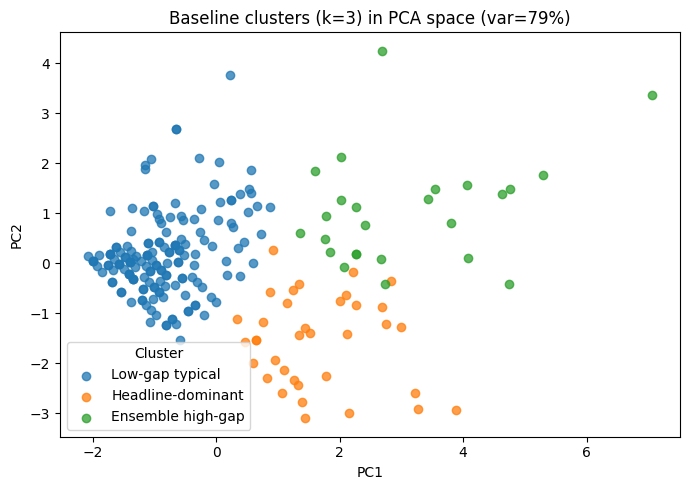

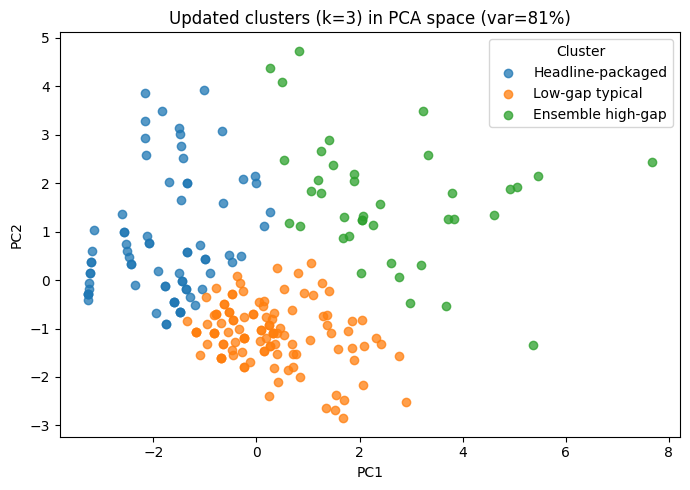

In [66]:
#function for PCA plot
def pca_scatter_named(df, feat_cols, label_col, title):
    # scale features
    X = df[feat_cols].copy().fillna(df[feat_cols].median(numeric_only=True))
    Xs = StandardScaler().fit_transform(X)

    # PCA to 2D
    pca = PCA(n_components=2, random_state=42)
    Z = pca.fit_transform(Xs)
    var = pca.explained_variance_ratio_.sum()

    # plot one color per cluster name
    plt.figure(figsize=(7,5))
    for name in df[label_col].unique():
        mask = df[label_col] == name
        plt.scatter(Z[mask, 0], Z[mask, 1], alpha=0.75, label=name)

    plt.title(f"{title} (var={var:.0%})")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend(title="Cluster", loc="best")
    plt.tight_layout()
    plt.show()

baseline_feats = ["top_gap_dominance", "second_gap", "median_gap", "count_large", "n_couples"]
updated_feats  = baseline_feats + ["headline_share", "hhi_gap"]

# Baseline PCA
pca_scatter_named(movie_compare, baseline_feats, "cluster_base_name",
                  "Baseline clusters (k=3) in PCA space")

# Updated PCA
pca_scatter_named(movie_compare, updated_feats, "cluster_up_name",
                  "Updated clusters (k=3) in PCA space")

- **Baseline PCA:** The baseline PCA plot shows three fairly distinct groups while still capturing most of the variation in the baseline features (~79%). This suggests the original M3 variables already contain meaningful structure, largely separating films by overall gap magnitude and how dominant the largest couple is relative to the rest.  
- **Updated PCA:** After adding the packaging features (**headline_share** and **HHI**), the PCA map shifts slightly and the clusters reorganize while still explaining a high share of variance (~81%). This aligns with the moderate baseline–updated agreement (ARI≈0.40, NMI≈0.49), indicating the refinement meaningfully changes groupings by emphasizing **within-film concentration** rather than only the top two gaps.

**Packaging-space plot (Updated): headline_share vs HHI**

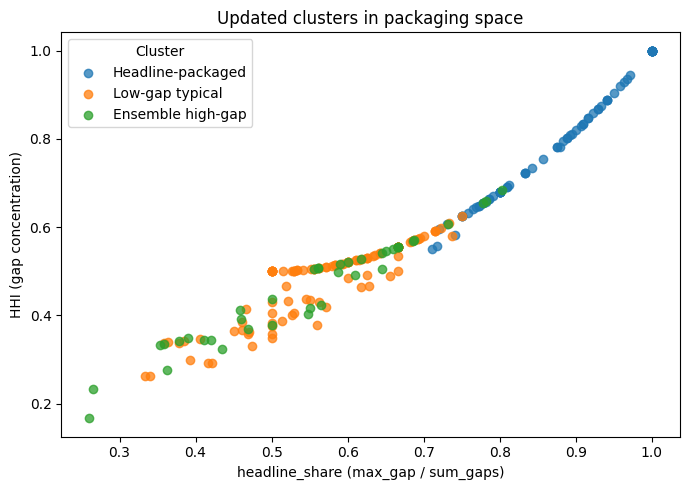

In [67]:
plt.figure(figsize=(7,5))

for name in movie_compare["cluster_up_name"].unique():
    mask = movie_compare["cluster_up_name"] == name
    plt.scatter(
        movie_compare.loc[mask, "headline_share"],
        movie_compare.loc[mask, "hhi_gap"],
        alpha=0.75,
        label=name
    )

plt.title("Updated clusters in packaging space")
plt.xlabel("headline_share (max_gap / sum_gaps)")
plt.ylabel("HHI (gap concentration)")
plt.legend(title="Cluster", loc="best")
plt.tight_layout()
plt.show()

In the packaging-space scatterplot, each point is a movie plotted by its **headline_share** (how much of the total age-gap comes from the single largest-gap couple) and **HHI** (how concentrated the gaps are across couples). Movies toward the **top-right** have both high headline_share and high HHI, meaning one couple largely drives the movie’s age-gap profile. In our updated clustering, the **Headline-packaged** group sits most strongly in this high-concentration region, while **Low-gap typical** and **Ensemble high-gap** tend to fall lower, showing that the new features separate movies based on *how* gaps are distributed within a film, not just how large the biggest gap is.

## 5) Linking Movie Clusters to Couple-Level Outcomes

This block maps the **updated movie-level cluster labels** back onto the original **couple-level rows**, so each couple inherits the cluster of its movie. We then summarize key couple outcomes by cluster—**mean age gap**, **% Rule-of-7 violations**, and **% older-man pairings**, to validate that the clusters correspond to meaningful relationship patterns.

In [69]:
# Map updated cluster names back to couple-level rows
movie_cluster_map = movie_compare[movie_key + ["cluster_up_name"]].copy()
couples_named = df.merge(movie_cluster_map, on=movie_key, how="inner")

# Validation summary by cluster
validation = (
    couples_named.groupby("cluster_up_name")
        .agg(
            n_couples=("age_gap", "size"),
            pct_rule_violation=("rule_violation", "mean"),
            pct_older_man=("directionality", lambda s: (s == "older_man").mean()),
            mean_gap=("age_gap", "mean")
        )
        .reset_index()
)

validation["pct_rule_violation"] = (validation["pct_rule_violation"] * 100).round(1)
validation["pct_older_man"] = (validation["pct_older_man"] * 100).round(1)
validation["mean_gap"] = validation["mean_gap"].round(2)

display(validation)

,cluster_up_name,n_couples,pct_rule_violation,pct_older_man,mean_gap
0,Low-gap typical,281,18.1,73.0,7.35
1,Headline-packaged,153,24.2,75.8,8.85
2,Ensemble high-gap,107,58.9,91.6,19.58


- **Low-gap typical** films have the smallest average gaps (mean ≈ 7.35) and the lowest Rule-of-7 violation rate (18.1%), making them the most “norm-consistent” group.
- **Headline-packaged** films have slightly larger gaps (mean ≈ 8.85) and a higher violation rate (24.2%), consistent with the idea that a standout couple drives the movie’s gap profile.
- **Ensemble high-gap** films are fundamentally different: they have very large average gaps (mean ≈ 19.58), a much higher violation rate (58.9%), and the strongest skew toward **older-man** pairings (91.6%), indicating that extreme gaps and directionality are concentrated in this segment.

**Conclusion:**

Overall, adding the packaging metrics **headline_share** and **HHI** meaningfully refines the M3 movie clusters by separating films where one couple dominates the age-gap profile from films where gaps are more evenly distributed. The updated segmentation keeps the **Ensemble high-gap** group clearly identifiable while making the “typical” movies easier to interpret as either **low-gap** or **headline-packaged**. Mapping clusters back to couple-level outcomes also shows these segments align with real differences in **Rule-of-7 violations** and **older-man directionality**, supporting that the refined clusters capture meaningful relationship patterns rather than noise.